In [ ]:
# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier

In [ ]:
# import csv file
df = pd.read_csv(r'/Diwali Sales Data.csv',encoding= 'unicode_escape')

FileNotFoundError: [Errno 2] No such file or directory: '/Diwali Sales Data.csv'

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Display initial shape and clean data
print("Original DataFrame Shape:", df.shape)
df.drop(['Status', 'unnamed1'], axis=1, inplace=True) # Drop unrelated/blank columns
df.dropna(inplace=True) # Drop null values (inplace=True modifies df directly)
df['Amount'] = df['Amount'].astype('int') # Change 'Amount' data type to integer


Original DataFrame Shape: (11251, 15)


In [ ]:
print("\nCleaned DataFrame Info after initial steps:")
df.info() # Display DataFrame's structure and dtypes after basic cleaning


Cleaned DataFrame Info after initial steps:
<class 'pandas.core.frame.DataFrame'>
Index: 11239 entries, 0 to 11250
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   User_ID           11239 non-null  int64 
 1   Cust_name         11239 non-null  object
 2   Product_ID        11239 non-null  object
 3   Gender            11239 non-null  object
 4   Age Group         11239 non-null  object
 5   Age               11239 non-null  int64 
 6   Marital_Status    11239 non-null  int64 
 7   State             11239 non-null  object
 8   Zone              11239 non-null  object
 9   Occupation        11239 non-null  object
 10  Product_Category  11239 non-null  object
 11  Orders            11239 non-null  int64 
 12  Amount            11239 non-null  int64 
dtypes: int64(5), object(8)
memory usage: 1.2+ MB


In [ ]:
# Normalization for numerical columns ('Age', 'Orders', 'Amount')
scaler_minmax = MinMaxScaler()
df[['Age', 'Orders', 'Amount']] = scaler_minmax.fit_transform(df[['Age', 'Orders', 'Amount']])
print("\nNumerical columns (Age, Orders, Amount) normalized using MinMaxScaler.")


Numerical columns (Age, Orders, Amount) normalized using MinMaxScaler.


In [ ]:
# Label Encoding for all categorical columns
categorical_cols = df.select_dtypes(include='object').columns
le = LabelEncoder()
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])
print("All categorical columns label encoded.")
print("DataFrame head after full preprocessing:\n", df.head()) # Show final state of df head

All categorical columns label encoded.
DataFrame head after full preprocessing:
    User_ID  Cust_name  Product_ID  Gender  Age Group     Age  Marital_Status  \
0  1002903        991         774       0          2  0.2000               0   
1  1000732        596         644       0          2  0.2875               1   
2  1001990        150         714       0          2  0.2875               1   
3  1001425       1102        1507       1          0  0.0500               0   
4  1000588        574         387       1          2  0.2000               1   

   State  Zone  Occupation  Product_Category    Orders    Amount  
0     10     4           8                 0  0.000000  1.000000  
1      0     3           7                 0  0.666667  0.999243  
2     14     0           1                 0  0.666667  0.998822  
3      7     3           5                 0  0.333333  0.998317  
4      3     4           6                 0  0.333333  0.996844  


In [ ]:
# Create binary target 'HighSpender' based on 75th percentile of 'Amount'
threshold = df['Amount'].quantile(0.75)
df['HighSpender'] = (df['Amount'] > threshold).astype(int)
print("\n'HighSpender' binary target created (1 if Amount > 75th percentile, else 0).")
print("HighSpender Value Counts:\n", df['HighSpender'].value_counts())


'HighSpender' binary target created (1 if Amount > 75th percentile, else 0).
HighSpender Value Counts:
 HighSpender
0    8429
1    2810
Name: count, dtype: int64


In [ ]:
# --- Concise Exploratory Data Analysis (EDA) ---
print("\n--- Concise Exploratory Data Analysis (EDA) ---")
sns.set_style("whitegrid") # Set a consistent visual style for plots


--- Concise Exploratory Data Analysis (EDA) ---


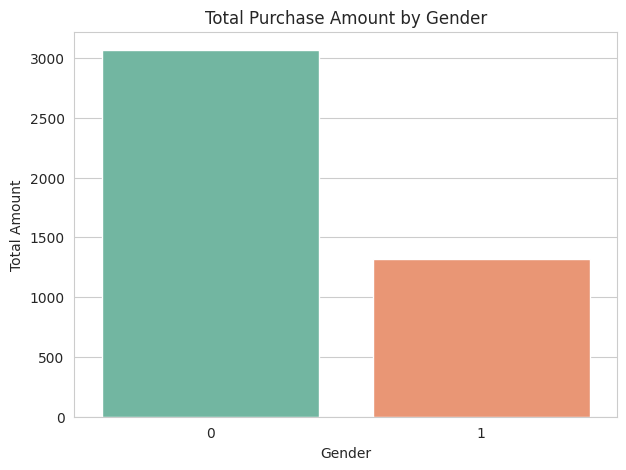

Insight: Most buyers are females, and their total purchasing power is greater than men.


In [ ]:
# Gender Analysis: Total Purchase Amount
plt.figure(figsize=(7, 5))
sales_gen = df.groupby(['Gender'], as_index=False)['Amount'].sum().sort_values(by='Amount', ascending=False)
sns.barplot(x='Gender', y='Amount', data=sales_gen, hue='Gender', palette='Set2', legend=False)
plt.title('Total Purchase Amount by Gender')
plt.xlabel('Gender')
plt.ylabel('Total Amount')
plt.show()
print("Insight: Most buyers are females, and their total purchasing power is greater than men.")

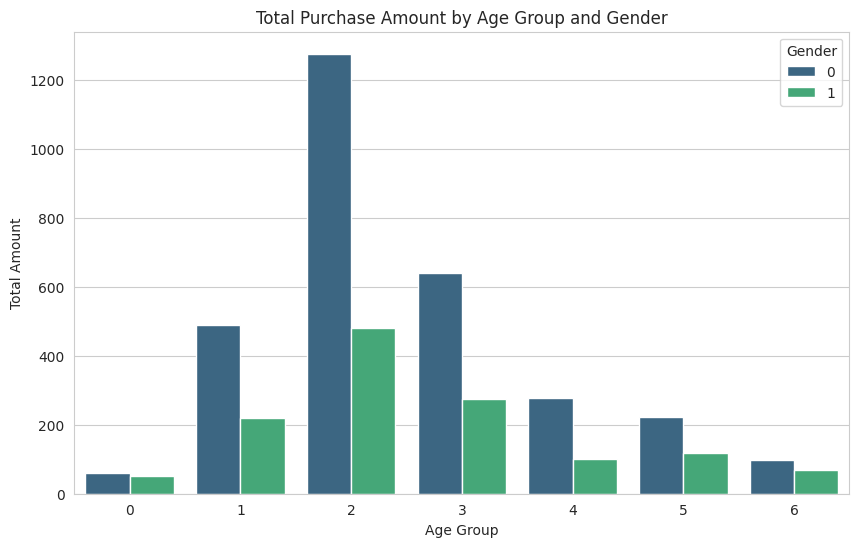

Insight: The 26-35 years age group, particularly females, accounts for the highest purchases.


In [ ]:
# Age Group Analysis: Total Purchase Amount by Age Group & Gender
plt.figure(figsize=(10, 6))
sales_age_gender = df.groupby(['Age Group', 'Gender'], as_index=False)['Amount'].sum().sort_values(by='Amount', ascending=False)
sns.barplot(x='Age Group', y='Amount', hue='Gender', data=sales_age_gender, palette='viridis')
plt.title('Total Purchase Amount by Age Group and Gender')
plt.xlabel('Age Group')
plt.ylabel('Total Amount')
plt.show()
print("Insight: The 26-35 years age group, particularly females, accounts for the highest purchases.")

/tmp/ipython-input-2098798418.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sales_state_orders, x='State', y='Orders', palette='crest')


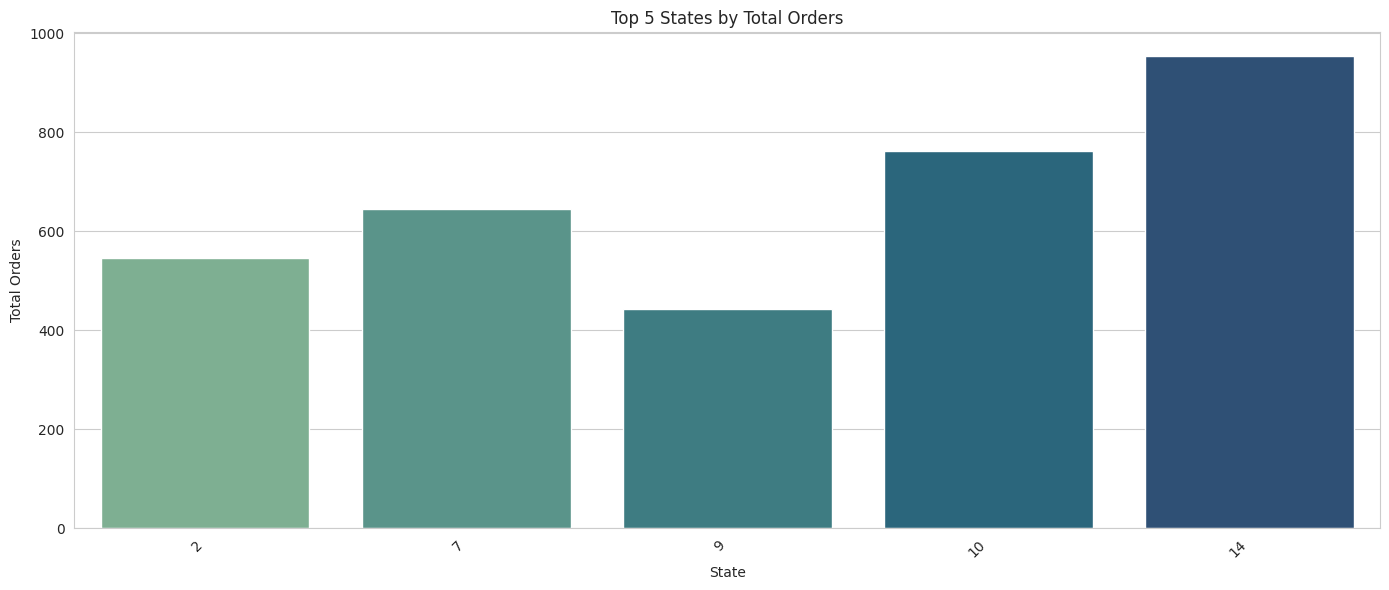

In [ ]:
# State Analysis: Top 5 States by Orders and Total Amount
plt.figure(figsize=(14, 6))
sales_state_orders = df.groupby(['State'], as_index=False)['Orders'].sum().nlargest(5, 'Orders')
sns.barplot(data=sales_state_orders, x='State', y='Orders', palette='crest')
plt.title('Top 5 States by Total Orders')
plt.xlabel('State')
plt.ylabel('Total Orders')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


/tmp/ipython-input-304037434.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sales_state_amount, x='State', y='Amount', palette='rocket')


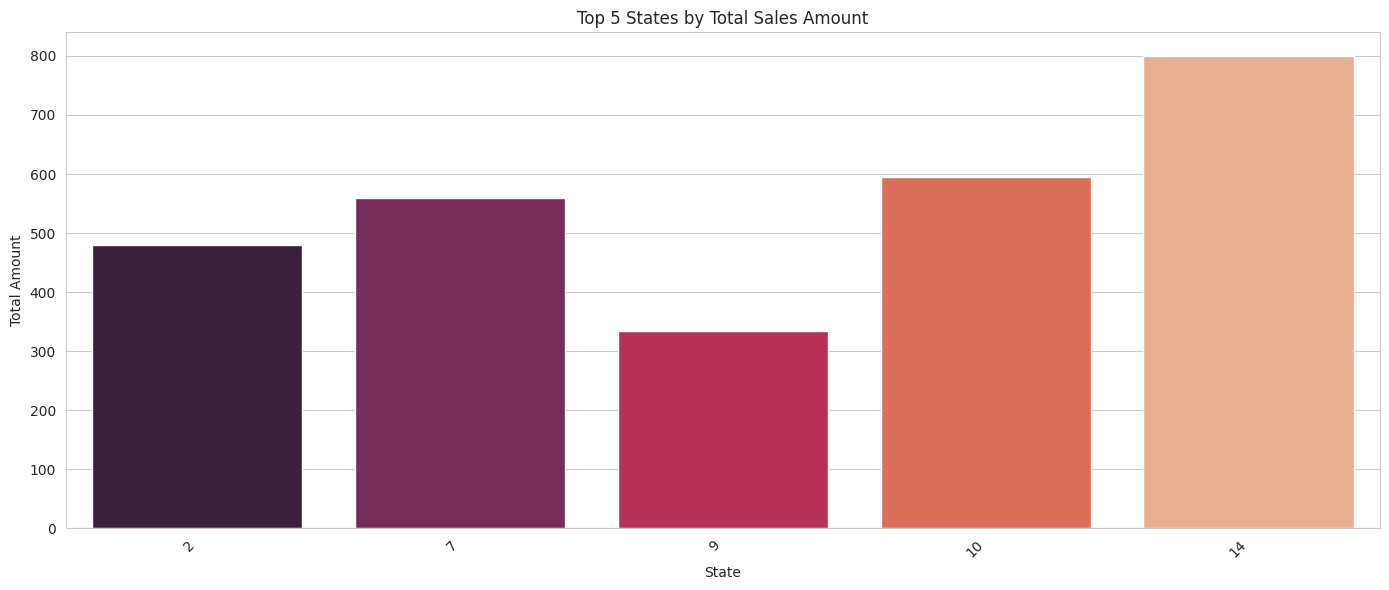

Insight: Uttar Pradesh, Maharashtra, and Karnataka consistently lead in both total orders and sales amount.


In [ ]:
plt.figure(figsize=(14, 6))
sales_state_amount = df.groupby(['State'], as_index=False)['Amount'].sum().nlargest(5, 'Amount')
sns.barplot(data=sales_state_amount, x='State', y='Amount', palette='rocket')
plt.title('Top 5 States by Total Sales Amount')
plt.xlabel('State')
plt.ylabel('Total Amount')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
print("Insight: Uttar Pradesh, Maharashtra, and Karnataka consistently lead in both total orders and sales amount.")


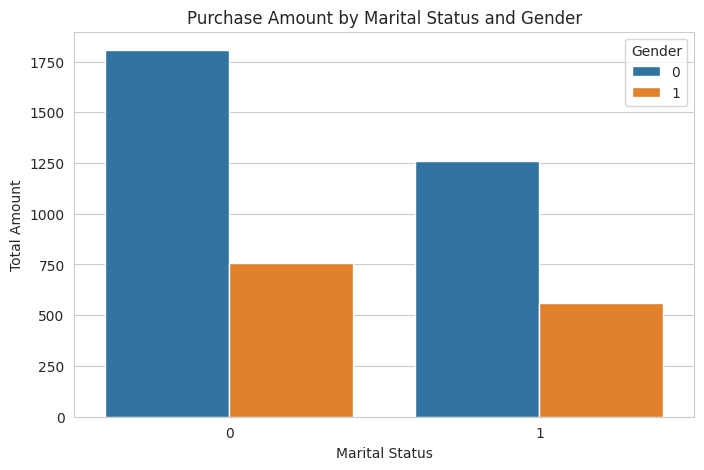

Insight: Married women are the primary buyers with significant purchasing power.


In [ ]:
# Marital Status Analysis: Total Purchase Amount by Marital Status & Gender
plt.figure(figsize=(8, 5))
sales_marital_gender = df.groupby(['Marital_Status', 'Gender'], as_index=False)['Amount'].sum().sort_values(by='Amount', ascending=False)
sns.barplot(data=sales_marital_gender, x='Marital_Status', y='Amount', hue='Gender')
plt.title('Purchase Amount by Marital Status and Gender')
plt.xlabel('Marital Status')
plt.ylabel('Total Amount')
plt.show()
print("Insight: Married women are the primary buyers with significant purchasing power.")

/tmp/ipython-input-2779862410.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sales_occupation, x='Occupation', y='Amount', palette='dark')


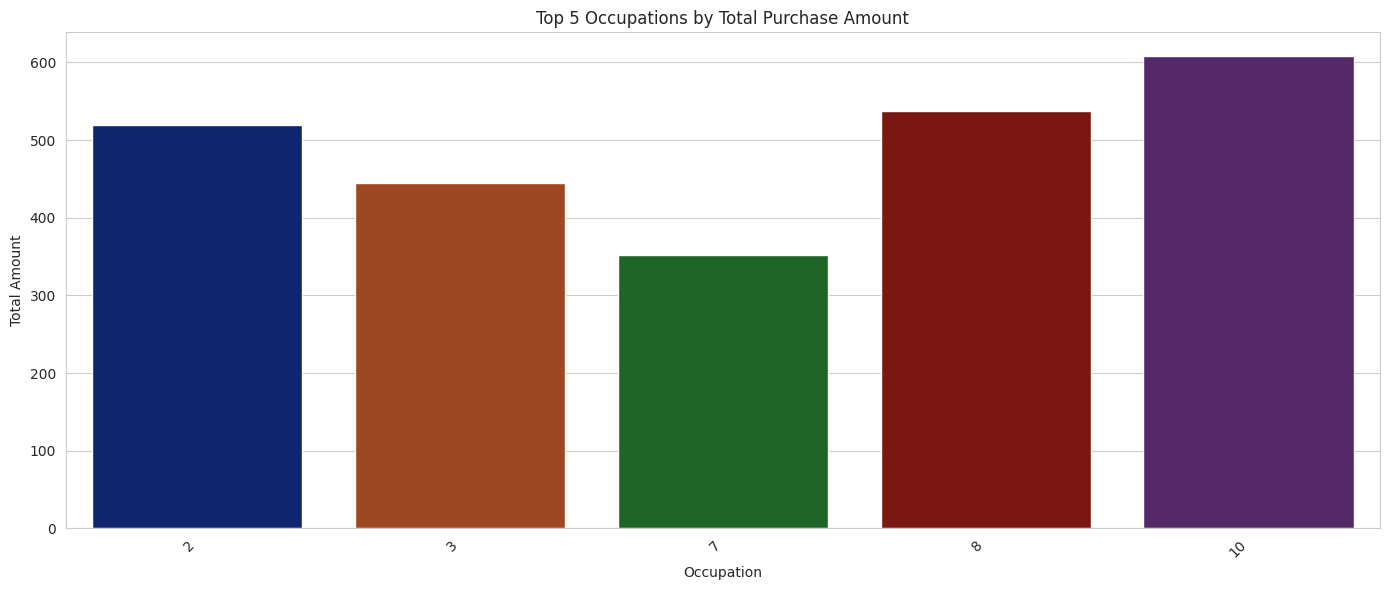

Insight: Customers from IT, Healthcare, and Aviation sectors are the highest spenders.


In [ ]:
# Occupation Analysis: Top 5 Occupations by Total Purchase Amount
plt.figure(figsize=(14, 6))
sales_occupation = df.groupby(['Occupation'], as_index=False)['Amount'].sum().nlargest(5, 'Amount')
sns.barplot(data=sales_occupation, x='Occupation', y='Amount', palette='dark')
plt.title('Top 5 Occupations by Total Purchase Amount')
plt.xlabel('Occupation')
plt.ylabel('Total Amount')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
print("Insight: Customers from IT, Healthcare, and Aviation sectors are the highest spenders.")

/tmp/ipython-input-1171602098.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sales_product_category, x='Product_Category', y='Amount', palette='Spectral')


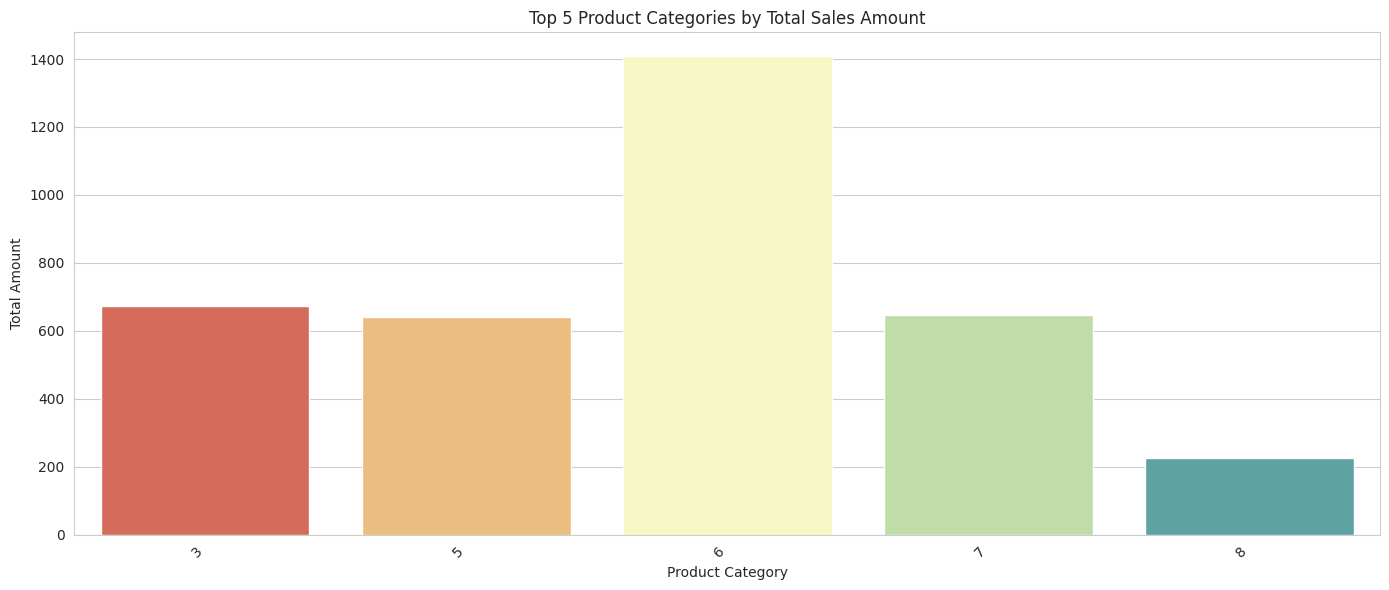

Insight: Food, Clothing, and Electronics are the top-selling product categories by amount.


In [ ]:
# Product Category Analysis: Top 5 Product Categories by Total Sales Amount
plt.figure(figsize=(14, 6))
sales_product_category = df.groupby(['Product_Category'], as_index=False)['Amount'].sum().nlargest(5, 'Amount')
sns.barplot(data=sales_product_category, x='Product_Category', y='Amount', palette='Spectral')
plt.title('Top 5 Product Categories by Total Sales Amount')
plt.xlabel('Product Category')
plt.ylabel('Total Amount')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
print("Insight: Food, Clothing, and Electronics are the top-selling product categories by amount.")

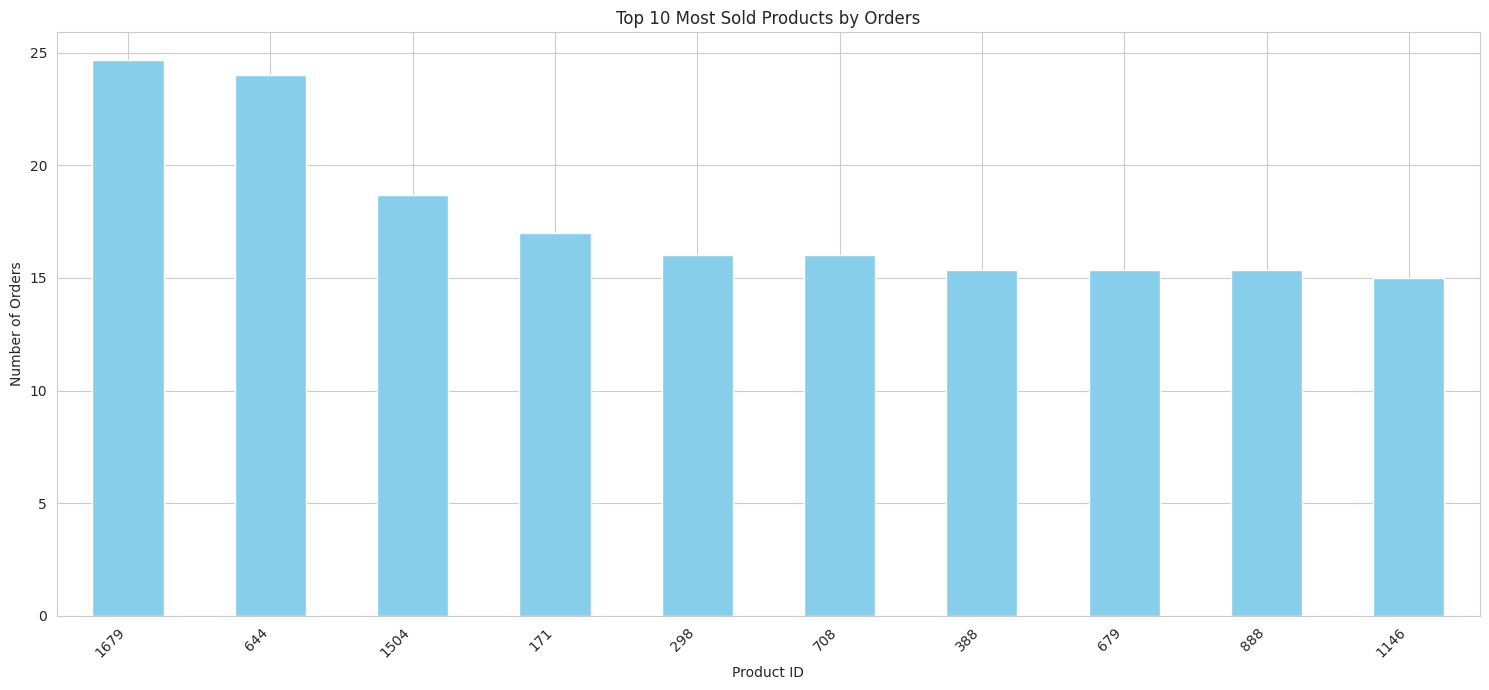

Insight: Specific product IDs leading in orders can be identified for targeted promotions.


In [ ]:
# Top 10 Most Sold Products by Orders
plt.figure(figsize=(15, 7))
df.groupby('Product_ID')['Orders'].sum().nlargest(10).sort_values(ascending=False).plot(kind='bar', color='skyblue')
plt.title('Top 10 Most Sold Products by Orders')
plt.xlabel('Product ID')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
print("Insight: Specific product IDs leading in orders can be identified for targeted promotions.")

In [ ]:
# --- 3. Machine Learning Model Building and Evaluation ---
print("\n--- 3. Machine Learning Model Building and Evaluation ---")


--- 3. Machine Learning Model Building and Evaluation ---


In [ ]:
# Define features (X) and target (y)
X = df.drop(columns=['HighSpender', 'Amount']) # Drop target and original 'Amount' to avoid data leakage
y = df['HighSpender']


In [ ]:
# Split data into training and testing sets (stratified to ensure class balance)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
print(f"Data split: Training samples = {X_train.shape[0]}, Test samples = {X_test.shape[0]}")

Data split: Training samples = 8991, Test samples = 2248


In [ ]:
# Apply SMOTE to fix class imbalance in the training set
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)
print(f"Training set resampled with SMOTE. Original balance: {y_train.value_counts().tolist()} -> Resampled balance: {y_train_resampled.value_counts().tolist()}")

Training set resampled with SMOTE. Original balance: [6743, 2248] -> Resampled balance: [6743, 6743]


In [ ]:
# Scale features for models that require it (e.g., Logistic Regression)
scaler_standard = StandardScaler()
X_train_scaled = scaler_standard.fit_transform(X_train_resampled)
X_test_scaled = scaler_standard.transform(X_test)
print("Features scaled using StandardScaler.")

Features scaled using StandardScaler.


In [ ]:
# Train and Evaluate Logistic Regression Model
print("\n### Logistic Regression Model Performance ###")
model_lr = LogisticRegression(max_iter=1000, random_state=42) # Added random_state for reproducibility
model_lr.fit(X_train_scaled, y_train_resampled)
y_pred_lr = model_lr.predict(X_test_scaled)


### Logistic Regression Model Performance ###


In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))
print("Classification Report:\n", classification_report(y_test, y_pred_lr))

Accuracy: 0.6236654804270463
Confusion Matrix:
 [[1174  512]
 [ 334  228]]
Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.70      0.74      1686
           1       0.31      0.41      0.35       562

    accuracy                           0.62      2248
   macro avg       0.54      0.55      0.54      2248
weighted avg       0.66      0.62      0.64      2248



In [ ]:
# Train and Evaluate Random Forest Classifier Model
print("\n### Random Forest Classifier Model Performance ###")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42) # Added random_state for reproducibility
rf_model.fit(X_train, y_train) # Random Forest often performs well on unscaled data
y_pred_rf = rf_model.predict(X_test)


### Random Forest Classifier Model Performance ###


In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("Classification Report:\n", classification_report(y_test, y_pred_rf))

Accuracy: 0.8185053380782918
Confusion Matrix:
 [[1473  213]
 [ 195  367]]
Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.87      0.88      1686
           1       0.63      0.65      0.64       562

    accuracy                           0.82      2248
   macro avg       0.76      0.76      0.76      2248
weighted avg       0.82      0.82      0.82      2248



In [ ]:
print("\n--- Overall Conclusion ---")
print("""The Random Forest Classifier model demonstrated strong predictive capability with an accuracy of approximately 82% on the test set.
This model can be effectively used to identify potential high-spending customers, guiding targeted marketing strategies.""")


--- Overall Conclusion ---
The Random Forest Classifier model demonstrated strong predictive capability with an accuracy of approximately 82% on the test set.
This model can be effectively used to identify potential high-spending customers, guiding targeted marketing strategies.
